> **在线运行说明。** 下一格安装 `coptpy`。内置的免费许可有规模上限，但足够跑通本案例。然后执行「运行所有」。


In [ ]:
# COPT Python API and this case's dependencies
!pip install -q coptpy matplotlib


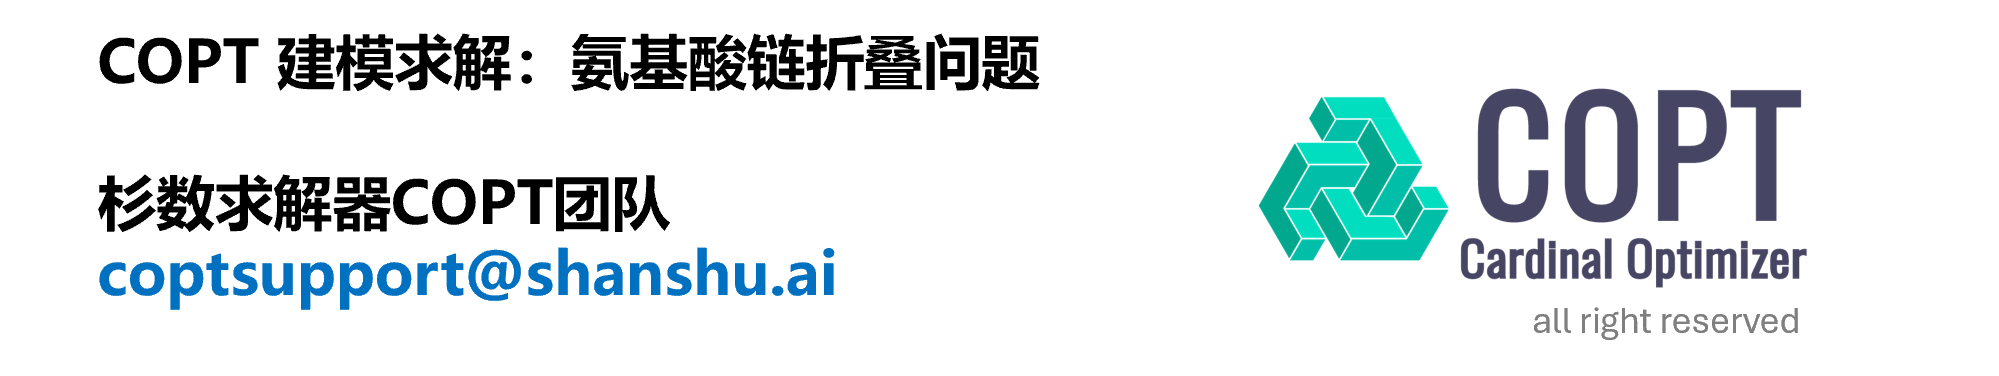

# 氨基酸链折叠问题代码实现
## 使用COPT建模求解氨基酸链折叠问题的步骤

1. **导入COPT-Python接口库** `coptpy`

2. **导入数据**
   - 导入氨基酸链的长度和疏水性氨基酸位置

3. **创建COPT求解环境与模型**

4. **构建模型：依次添加三要素**
   - **决策变量**：
      - 定义二进制变量 $edge_{i,j}$来表示每一对疏水性氨基酸(i, j)之间是否配对
      - 定义二进制变量fold_(i)来表示在索引 $i$ 和 $i + 1$ 的氨基酸之间是否发生折叠
   - **目标函数**：最大化配对数量
   - **约束条件**：
      - 配对的氨基酸之间的其他氨基酸的数目为偶数，且位置 $\frac{i + j - 1}{2}$ 处必须发生折叠
      - 配对的氨基酸之间，除了位置 $\frac{i + j - 1}{2}$ 之外不能发生折叠

5. **求解**

6. 查看、分析**结果**


## 导入COPT-Python接口库

In [4]:
import coptpy as cp
from coptpy import COPT

import matplotlib.pyplot as plt

## 添加模型数据

In [6]:
# 导入总链长度
len_chain = 50

# 导入疏水性氨基酸位置
hydrophobic = [2, 4, 5, 6, 11, 12, 17, 20, 21, 25, 27, 28, 30, 31, 33, 37, 44, 46]

# 注意，以下为另一套数据，请将二者配合使用
# len_chain = 27
# hydrophobic = [2, 3, 4, 6, 9, 11, 14, 16, 19, 22, 23, 26]

# 处理序号为索引
hydrophobic = [i - 1 for i in hydrophobic]

# 获取疏水性氨基酸数量
num_hydrophobic = len(hydrophobic)

# 预处理决策变量的边
pair_hydrophobic = [(hydrophobic[i], hydrophobic[j]) for i in range(num_hydrophobic) for j in range(i + 2, num_hydrophobic)]

# 获得配对数量
num_pair = len(pair_hydrophobic)


## 创建求解环境和求解模型

In [8]:
env = cp.Envr()
model = env.createModel()

Cardinal Optimizer v8.0.5. Build date May 30 2026
Copyright Cardinal Operations 2026. All Rights Reserved



## 添加模型三要素

### 添加决策变量
1. 为每一对疏水性氨基酸之间添加一个二进制变量用于表示其是否配对
$$
    \text{edge}_{i, j} = \begin{cases}
        1, & \text{位置$i$与位置$j$的氨基酸互相配对} \\
        0, & \text{位置$i$与位置$j$的氨基酸没有配对}
    \end{cases}
$$

2. 为链上除最后一个外的每一个氨基酸添加二进制变量用于表示是否在该位置发生折叠
$$
    \text{fold}_i = \begin{cases}
        1, & \text{在位置 $i$ 与 $i + 1$ 发生折叠} \\
        0, & \text{在位置 $i$ 与 $i + 1$ 没有发生折叠}
    \end{cases}
$$

In [10]:
edge = model.addVars(pair_hydrophobic, vtype=COPT.BINARY, nameprefix='edge')
fold = model.addVars(len_chain - 1, vtype=COPT.BINARY, nameprefix='fold')

### 设置目标函数
目标为最大化总配对数量
$$
    \max \, \sum_{(i, j)}\text{edge}_{i, j}
$$

In [12]:
model.setObjective(cp.quicksum(edge), sense=COPT.MAXIMIZE)

### 添加约束条件
1. 配对的氨基酸之间的其他氨基酸的数目为偶数，且位置 $\frac{i + j - 1}{2}$ 处必须发生折叠
$$
\begin{cases}
    \text{edge}_{i, j} = 0, & \text{若 $\frac{i + j - 1}{2}$ 不为整数} \\
    \text{edge}_{i, j} \leq \text{fold}_{\frac{i + j - 1}{2}}, & \text{若 $\frac{i + j - 1}{2}$ 为整数}
\end{cases}
$$

In [14]:
for i in range(len_chain):
    for j in range(i + 2, len_chain):
        if (i, j) not in pair_hydrophobic:
            continue
        if (j + i - 1) / 2 != int((j + i - 1) / 2):
            model.addConstr(edge[(i, j)] == 0)
        else:
            model.addConstr(edge[(i, j)] <= fold[int((i + j - 1) / 2)])
                

2. 配对的氨基酸之间，除了位置 $\frac{i + j - 1}{2}$ 之外不能发生折叠
$$
    \text{edge}_{i, j} + \text{fold}_{k} \leq 1, \, \forall \, k \in [i, j), k \neq \frac{i + j - 1}{2}
$$

In [16]:
for i in range(len_chain):
    for j in range(i + 2, len_chain):
        if (i, j) not in pair_hydrophobic:
            continue
        for u in range(i, j):
            if u != (i + j - 1) / 2:
                model.addConstr(edge[(i, j)] + fold[u] <= 1)

## 求解

In [18]:
model.solve()

Model fingerprint: e8a32521

Using Cardinal Optimizer v8.0.5 on Windows (22H2 Build 19045 - x86_64)
The CPU model is Intel(R) Core(TM) i5-10210U CPU @ 1.60GHz
Hardware has 4 physical cores and 8 logical cores. Using instruction set X86_AVX2 (10)
Maximizing a MIP problem

The original problem has:
    2468 rows, 185 columns and 4871 non-zero elements
    185 binaries

Starting the MIP solver with 8 threads and 32 tasks

Presolving the problem

The presolved problem has:
    832 rows, 90 columns and 2055 non-zero elements
    90 binaries

Problem info:
    Range of matrix coefficients:    [1e+00,1e+00]
    Range of rhs coefficients:       [1e+00,1e+00]
    Range of bound coefficients:     [1e+00,1e+00]
    Range of cost coefficients:      [1e+00,1e+00]
    Density of cost:                     73.3%

     Nodes    Active  LPit/n  IntInf     BestBound  BestSolution     Gap   Time
         0         1      --       0  6.600000e+01            --     Inf  0.11s
H        0         1      --   

## 获取结果

最大连接数为8.0


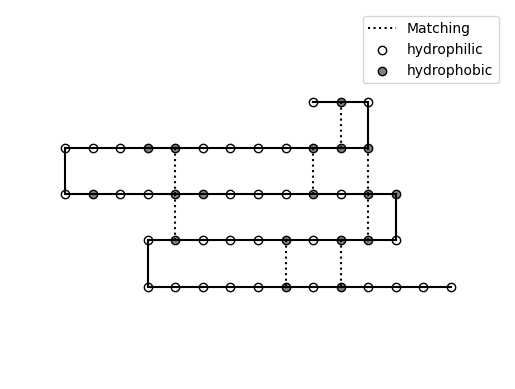

In [20]:
if model.status == COPT.OPTIMAL:
    print(f'最大连接数为{round(model.objval, 0)}')
    variables = model.getVars()
    x = 0
    y = 0
    dir = 1
    min_x = 0
    max_x = 0
    min_y = 0
    max_y = 0
    coordinate = []
    # 计算点的位置
    for i in range(len_chain):
        coordinate.append([x, y])
        max_x = max(max_x, x)
        min_x = min(min_x, x)
        max_y = max(max_y, y)
        min_y = min(min_y, y)
        # 计算下一个点位置
        if i != len_chain - 1 and variables[i + num_pair].x >= 0.9:
            y -= 1
            dir *= -1
        else:
            x += dir
        # 绘制链本体线段
        if i != len_chain - 1:
            plt.plot([coordinate[-1][0], x], [coordinate[-1][1], y], linestyle='-', color='black')
    # 绘制新增连线
    index = 0
    mark = 1
    for item in pair_hydrophobic:
        if variables[index].x >= 0.9:
            if mark == 1:
                plt.plot([coordinate[item[0]][0], coordinate[item[1]][0]],
                        [coordinate[item[0]][1], coordinate[item[1]][1]], linestyle=':', color='black', label='Matching')
                mark = 0
            else:
                plt.plot([coordinate[item[0]][0], coordinate[item[1]][0]],
                        [coordinate[item[0]][1], coordinate[item[1]][1]], linestyle=':', color='black')
        index += 1
    # 绘制点
    mark_0 = 1
    mark_1 = 1
    for i in range(len_chain):
        if i in hydrophobic:
            if mark_0 == 1:
                plt.scatter(coordinate[i][0], coordinate[i][1], facecolors='gray', edgecolors='black', label='hydrophobic')
                mark_0 = 0
            else:
                plt.scatter(coordinate[i][0], coordinate[i][1], facecolors='gray', edgecolors='black')
        else:
            if mark_1 == 1:
                plt.scatter(coordinate[i][0], coordinate[i][1], facecolors='white', edgecolors='black', label='hydrophilic')
                mark_1 = 0
            else:
                plt.scatter(coordinate[i][0], coordinate[i][1], facecolors='white', edgecolors='black')
    plt.axis('off')
    plt.xlim(min_x - 2, max_x + 2)
    plt.ylim(min_y - 2, max_y + 2)
    plt.legend()
    plt.show()
else:
    print('未找到最优解')